# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [3]:
# importar librerías
import pandas as pd
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt 

In [4]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [5]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [8]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [9]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [10]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:
# cantidad de nulos para users
print('Cantidad de valores nulos:', users.isna().sum())
print('Proporción de valores nulos:', users.isna().mean())


Cantidad de valores nulos: user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos: user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [13]:
# cantidad de nulos para usage
print('Cantidad de valores nulos:', usage.isna().sum())
print('Proporción de valores nulos:', usage.isna().mean())

Cantidad de valores nulos: id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos: id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Las columnas churn_date 88.35% y city 11.72% para users y para usage tenemos 3 columnas con faltantes date 0,12%, duration 55.19% y length 44.74%.
- Indica qué harías: ¿imputar, eliminar, ignorar?
- para users eliminaria churn_date y dejaria como nulos los faltantes de city
- para usage ignoraria los faltantes de date los dejaria como nulos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`  no tiene ninguna anomalia de nlso datos 
- La columna `age` aqui el minimo de -999 debe ser algun dato corrupto o erroneo, de resto todo se ve normal, probablemente la std se ve afectada por este numero atipico que hay que arreglar.

In [15]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`estan dentro de los rangos esperados.
- Las columnas `duration` tiene valores atipicos extremos de 0 que puede ser llamadas que no se pudieron responder o se fue la señal y la de 2 horas que tambien pueden ser casos de llamadas atipicas pero no improbables, de resto todo se ve dentor de lo esperado.]

In [16]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"-{col}-")
    print(users[col].value_counts(dropna=False))
    print()

-city-
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

-plan-
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` tiene 96 datos sin ciudad y con el signo "?" el resto de datos estan bien.
- La columna `plan` tiene todos los datos bien.

In [17]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False) 

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` no presenta anomalias.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [19]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [20]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False)

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [21]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False)

2024.0    39950
NaN          50
Name: date, dtype: int64

En `date`, la mayoria de los datos aparecen en el 2024 solo 50 fechas no estan NaN pero no estan en una fecha imposible simplemente no tienen registro, en cambio en `reg_date` si podemos apreciar que hay datos desde el 2022 hasta el 2024 y 40 que son imposibles en el 2026 ya que la base de datos solo deberia contar con informacion hasta el 2024. 

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print('Ciudades nulas:',users['city'].isna().sum())
print('conteo de interrogaciones:',(users['city'] == '?').sum())

Ciudades nulas: 565
conteo de interrogaciones: 0


In [24]:
# Marcar fechas futuras como NA para reg_date
#users['reg_date'] = users['reg_date'].replace((users['reg_date'] > '2024-12-31'), pd.NA)
users.loc[users['reg_date'] > '2024-12-31', 'reg_date'] = pd.NaT
# Verificar cambios
print('Fechas nulas:',users['reg_date'].isna().sum())
print('conteo de interrogaciones:',(users['reg_date'] > '2024-12-31').sum())
print(users['reg_date'].max())

Fechas nulas: 40
conteo de interrogaciones: 0
2024-12-31 00:00:00


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
# Verificación MAR en usage (Missing At Random) para duration
missing_duration = usage['duration'].isna().groupby(usage['type']).mean()
missing_duration

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [26]:
# Verificación MAR en usage (Missing At Random) para length
missing_length = usage['length'].isna().groupby(usage['type']).mean()
missing_length

type
call    0.99933
text    0.00000
Name: length, dtype: float64

En `duration` podemos apreciar que el 99.92% de los textos estan como NaN y todas las llamadas  si tienen valores de duracion y `length` pasa al revez 99.93% de call en NaN y text no tiene ninguna faltante, lo uqe quiere decir que la variable de length solo es valida o se usa especificamente para medir mansajes de texto y calls se mide con duration pero, los datos son MAR ya que tenemos la explicacion logica de porque en cada tipo se presentan los faltantes, se deben dejar como nulos ya que es el comportamiento esperado. 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text','is_call','duration']].sum()

# observar resultado
usage_agg.head(3)

,is_text,is_call,duration
user_id,,,
10000,7,3,23.70
10001,5,10,33.18
10002,5,2,10.74


In [28]:
# Renombrar columnas
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
cols_uso = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[cols_uso] = user_profile[cols_uso].fillna(0)
user_profile = user_profile.drop(columns=['churn_date'])
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [30]:
# Resumen estadístico de las columnas numéricas
col_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[col_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.122250,5.523000,4.477000,23.311225
std,17.690408,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


In [31]:
# Distribución porcentual del tipo de plan
col_categoricas = 'plan'
user_profile[col_categoricas].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

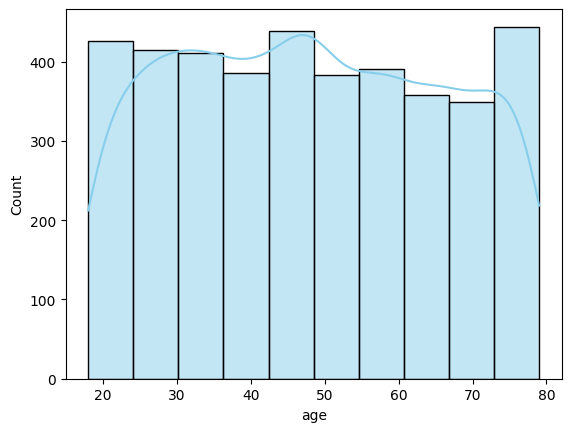

In [32]:
# Histograma para visualizar la edad (age)
sns.histplot(user_profile['age'], bins=10, color='skyblue', kde=True)
plt.show()

💡Insights: 
- Distribución se ve muy pareja y no tenemos un valor atipico, podemos apreciar que unos de los grupos mas grandes de edad pero no por mucho son los de entre 40 y 50 años y de 75 a los 79 años. 

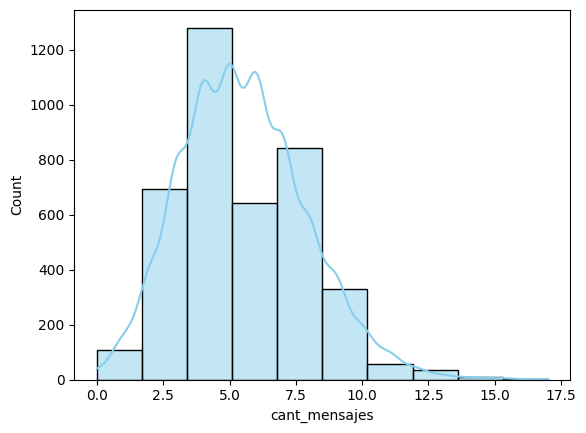

In [33]:
# Histograma para visualizar la cant_mensajes
sns.histplot(user_profile['cant_mensajes'], bins=10, color='skyblue', kde=True)
plt.show()

💡Insights: 
- la cantidad de mensajes comienza a tener un poco de desviacion a la derecha por algunos valores cercanos al 17, el resto de los valores oscilan entre 2.5 y 8 ahi se presenta la mayor concentracion. 

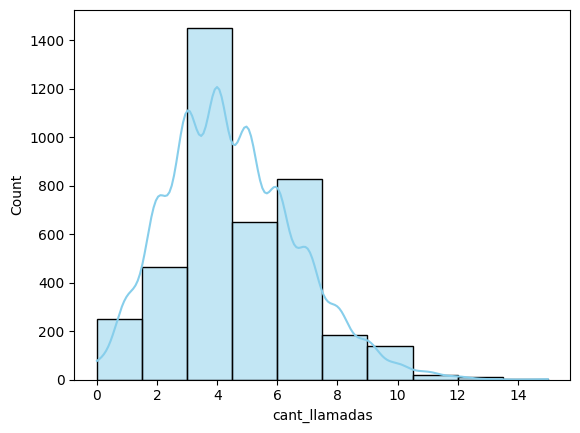

In [34]:
# Histograma para visualizar la cant_llamadas
sns.histplot(user_profile['cant_llamadas'], bins=10, color='skyblue', kde=True)
plt.show()

💡Insights: 
- Distribución observamos el mismo patron una desviacion hacia la derecha, por algunos valores que tienden a estar mas cerca de 14, pero cae dentro de la distribucion esperada, algunas personas deben utilizar mas el servicio de llamadas, o puede qeu tambien sean casos donde las lineas se utilicen para negocios, el resto de los valores esta concentrado en un promedio de 4 y sus alrededores.

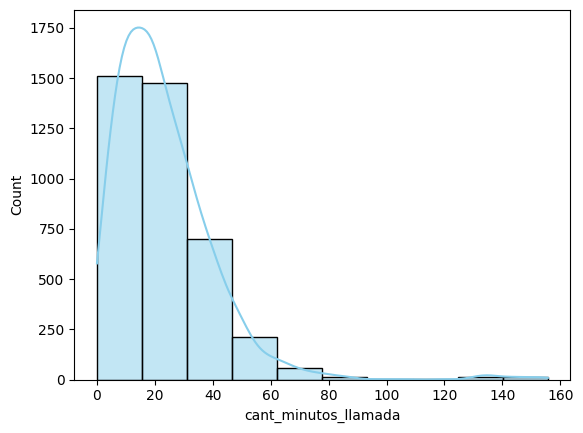

In [35]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile['cant_minutos_llamada'], bins=10, color='skyblue', kde=True)
plt.show()

💡Insights: 
- aqui si podemos apreciar una desvaicion muy definida a la derecha pro valores extremos en la cantidad de minutos por llamada, se tendria que estudiar si pudo ser algun tipo de error o algunos casos aislados de llamadas los que ocacionan tanta utilizacion de minutos, el resto de la curvo se maneja de manera normal con la mayoria de minutos utilizados entre 0 y 30 de promedio.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

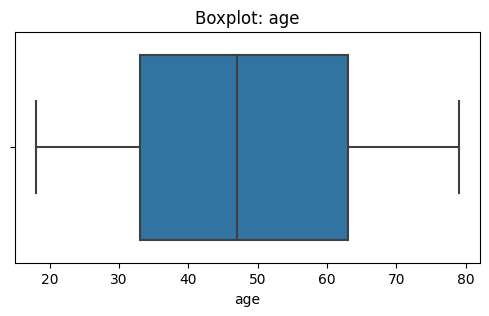

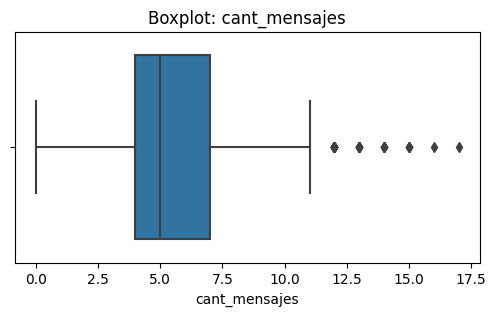

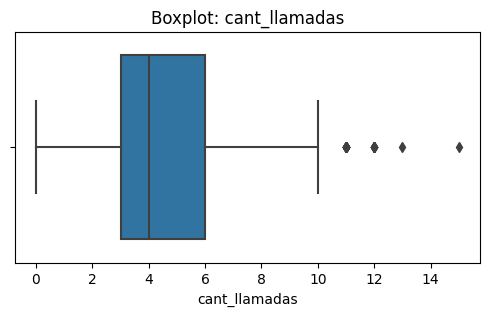

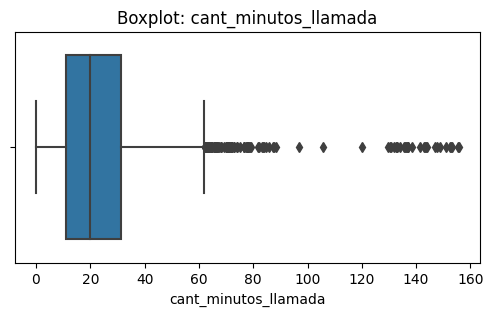

In [36]:
# Visualizando usando BoxPlot 
col_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in col_numericas:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: no presenta outliers 
- cant_mensajes y cant_llamadas: presentan outliers hacia la derecha, indica que hay personas que utilizan mucho estos servicios.
- cant_minutos_llamada: presenta una cantidad significativa de outliers, hay muchas personas que estan usando muchos minutos.

In [37]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

print('Primer cuartile:', Q1)
print('Tercer cuartile:', Q3)
print('IQR:', IQR)


print('nRegristros arriba del limite superiror')
print(user_profile[user_profile[col] > limite_superior])



Primer cuartile: 11.1075
Tercer cuartile: 31.4125
IQR: 20.305
nRegristros arriba del limite superiror
      user_id first_name last_name   age      city  \
27      10027        Ana     Gomez  28.0       MTY   
85      10085     Carlos   Ramirez  65.0       GDL   
93      10093        Ana    Torres  67.0  Medellín   
189     10189    Mariana    Torres  63.0       MTY   
198     10198      Sofia     Gomez  58.0  Medellín   
...       ...        ...       ...   ...       ...   
3920    13920    Mariana     Lopez  48.0    Bogotá   
3927    13927    Mariana     Lopez  18.0       GDL   
3945    13945       Luis   Ramirez  30.0    Bogotá   
3953    13953      Mateo     Gomez  58.0       GDL   
3967    13967     Carlos    Torres  72.0  Medellín   

                          reg_date     plan  cant_mensajes  cant_llamadas  \
27   2022-01-08 09:26:03.690922730  Premium            8.0            7.0   
85   2022-01-24 06:35:22.730682670   Basico            6.0            5.0   
93   2022-01-26 11

In [38]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes, cant_llamadas y cant_minutos_llamada: se decide mantener los outliers, dado el tipo de analiziz en genreal para las tres variables, podemos observar que no es algo 'imposible', ya uqe no hay ningun valor que sea algo anormal, mas bien estan mostrando un patron o el comportamiento de algunos de los clientes que utilizan mas estos servicios y se pueda analizar el porque he insetivarlos dependiendo del tipo de plan a que hagan un 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [50]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)
print(user_profile['grupo_uso'].value_counts())

Uso medio    2943
Bajo uso      779
Alto uso      278
Name: grupo_uso, dtype: int64


In [51]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [53]:
# Crear columna grupo_edad
def calsificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(calsificar_edad, axis=1)
print(user_profile['grupo_edad'].value_counts())

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [68]:
# verificar cambios
user_profile.head(10)

,user_id,first_name,last_name,age,city,reg_date,plan,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,4.0,3.0,8.01,Bajo uso,Adulto Mayor
5,10005,Luis,Garcia,61.0,MTY,2022-01-02 08:51:29.572393098,Basico,5.0,7.0,44.97,Uso medio,Adulto Mayor
6,10006,Sofia,Lopez,39.0,Bogotá,2022-01-02 15:25:47.486871717,Basico,3.0,5.0,28.39,Uso medio,Adulto
7,10007,Sofia,Gomez,70.0,Medellín,2022-01-02 22:00:05.401350337,Premium,3.0,5.0,30.23,Uso medio,Adulto Mayor
8,10008,Sofia,Garcia,76.0,CDMX,2022-01-03 04:34:23.315828957,Basico,5.0,5.0,28.85,Uso medio,Adulto Mayor
9,10009,Mateo,Torres,47.0,Bogotá,2022-01-03 11:08:41.230307576,Basico,5.0,3.0,5.99,Uso medio,Adulto


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

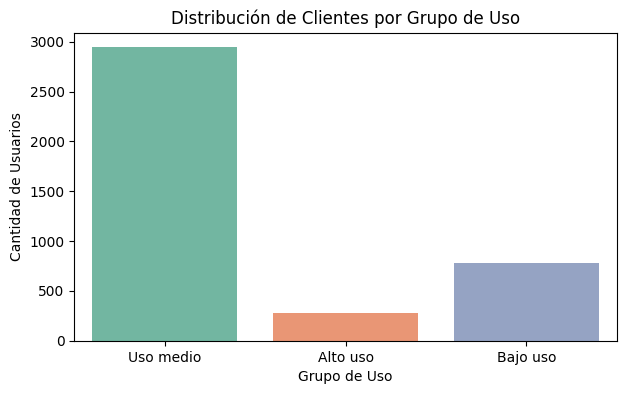

In [72]:
# Visualización de los segmentos por uso
plt.figure(figsize=(7,4))
sns.countplot(data=user_profile, x='grupo_uso', palette='Set2')
plt.title('Distribución de Clientes por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

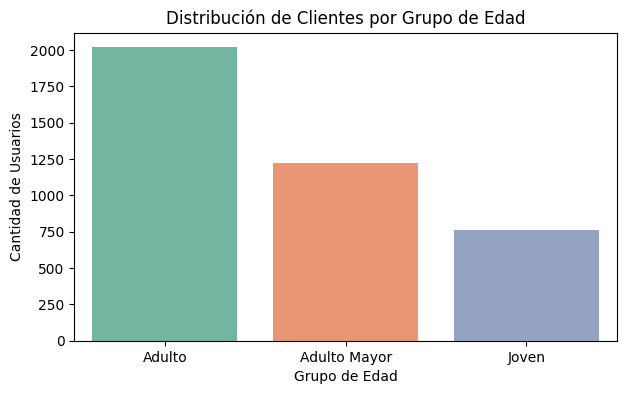

In [65]:
# Visualización de los segmentos por edad
plt.figure(figsize=(7,4))
sns.countplot(data=user_profile, x='grupo_edad', palette='Set2')
plt.title('Distribución de Clientes por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

In [79]:
user_profile.groupby('grupo_edad')[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].mean().round(2)

,cant_mensajes,cant_llamadas,cant_minutos_llamada
grupo_edad,,,
Adulto,5.55,4.48,22.99
Adulto Mayor,5.49,4.50,23.58
Joven,5.52,4.43,23.75


In [80]:
user_profile.groupby('grupo_uso')[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].mean().round(2)

,cant_mensajes,cant_llamadas,cant_minutos_llamada
grupo_uso,,,
Alto uso,9.56,5.95,30.15
Bajo uso,3.13,2.80,14.90
Uso medio,5.78,4.78,24.89


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Pudimos apreciar al principio que había algunas columnas con NaN y ?, aparte de esto el resto de los datos estaban bien, no había id raros ni atípicos los users estaban bien pero si teníamos unas variables para date algo esxtrañas a las cuales se les dio sentido luego. 
- Las columnas churn_date 88.35% con 3534 y city 11.72% con 469 para users y para usage tenemos 3 columnas con faltantes date 0,12%.
- Duration 55.19% con 22076 y length 44.74% con 17896, esto se da porque cada variable se usa específicamente para analizar o textos o duración de llamada, entonces es normal que aparezcan estos faltantes. 
- Se detectaron valores de -999 lo cual hay que corregir y valores de duration en 0 pero este de 0 específicamente puede ser una llamada que no conecto o que se corto justo cuando contestaron y esta bien, ta,bien vimos uqe la columna city tenia 96 datos sin ciudad con un '?'
- Se registraron 40 fechas en el 2026 lo cual representava un error en la fecha. 
- En age se remplazo todos los -999 con la mediana. En city remplazamos el sentinels '?' con NaN y se marcaron como nulas las fechas del 2026 


🔍 **Segmentos por Edad**
- En lo que podemos apreciar la distribucion de llamadas y mensajes, al igual que su duracion a lo largo de todas las edades se mantiene muy estable para todas las categorias.
- El porcentaje de proporcion de uso se concentra con casi el 51% de usuarios en la edad adulta (30-50 años), el otro 30% en Adulto Mayor y el otro 19% en Jovenes.
- Esto indica que la edad no es una variable calve para definir el volumen de uso de los servicios, pero si para saber en que rango de edad se encuentran la mayoria de los usuarios.


📊 **Segmentos por Nivel de Uso**
- Uso medio con 2943 equivale a 73% es el mas predominante esto quiere decir que la moayoria de los usuarios tienen un uso promedio de los servicios.
- uso bajo con 779 indica que al rededor de 19% del uso de los servicios es esporadio o de acciones concretas
- Alto uso con 278, indica que hay una cantidad muy baja menos del 7% de los usuarios son 'power users' que utilizan al maximo los planes de telefonia.


➡️ Esto sugiere que la mayoria de los usuarios con consumos muy grandes son aquellos que aprovechan al maximo su servicio o lo utilizan muy a menudo por algun  tipo de razon en especifico.


💡 **Recomendaciones**
- Puede que el segmento de alto uso no sea el del mayor porcentaje, pero se podría crear un plan que premie a la gente con puntos o algún tipo de incentivo en compras futuras dependiendo del uso o algún plan de minutos y textos ilimitados que sea mas atractivo para estas personas, de esta manera también se puede llegar a cautivar a ese 73% de usuarios que tienen un uso medio, ya sea que este pudiese llegar a estar en relación conque no tienen mas capacidad de minutos o texto y por esto pueden no estarlo usando mas, para "ahorrar" los que ya tienen para el mes. 

- La empresa no debería invertir recursos en campañas direccionadas a los grupos de edad, ya que se evidencio que es una variable nula en la cantidad de uso de los servicios. Si no enfocar las campañas publicitarias o de promociones en los grupos de uso.

- Otra estrategia teniendo en cuenta a los usuarios de uso medio que representan el 73% es generar reportes de consumo dentro de la app del consumidior, que les muestre si estan llegando justos al mes o si necesitan expandir su plan, tambien agendar notificaciones (un mensaje de texto) que alerte al cliente cuando llegue a un 70% o 80% de uso de sus servicios y pfrecerle aumentar su plan, decir algo como que si hace la mejora de plan en este momento tendra 1 mese de prueba de los servicios del pla 'Premium' con el precio de su plna naterior por este periodo de prueba y un descuento en los 2 siguientes meses si desea hacer la actualizacion total del plan del 30% en el valor del plan Premium. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`